#Personality Predictor - XGBoost

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,

)
import joblib

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load Data

In [50]:
df = pd.read_csv('/content/drive/MyDrive/Decryptogen/personality_dataset.csv')
print(f"Dataset shape:{df.shape}")
print(f"Target distribution:\n{df['Personality'].value_counts()}\n")

Dataset shape:(2900, 8)
Target distribution:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64



In [51]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


#Preprocsessing

In [52]:
df["Stage_fear"] = df["Stage_fear"].map({"Yes":1, "No":0})
df["Drained_after_socializing"] = df["Drained_after_socializing"].map({"Yes":1, "No":0})
df["Personality"] = df["Personality"].map({"Introvert":1, "Extrovert":0})

#Split features & Target

In [53]:
X = df.drop("Personality", axis=1)
y = df["Personality"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
print(f"Training samples shape: {X_train.shape}")
print(f"Testing samples shape: {X_test.shape}")
print(f"Features:{X.columns.tolist()}")

Training samples shape: (2320, 7)
Testing samples shape: (580, 7)
Features:['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']


#Train XGBoost Model

In [56]:
from google import colab
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)

model.fit(X_train, y_train)
print("Model trained Successfully!\n")

Model trained Successfully!



#Evaluate Model

In [57]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

In [58]:
print("="*45)
print(f" Test Accuracy   : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f" ROC AUC Score   : {auc:.4f}")
print(f" Cross Validation: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*45)
print()

print(classification_report(
    y_test,y_pred,
    target_names=["Introvert(0)", "Extrovert(1)"]
))

 Test Accuracy   : 0.9155 (91.6%)
 ROC AUC Score   : 0.9575
 Cross Validation: 0.9307 ± 0.0167

              precision    recall  f1-score   support

Introvert(0)       0.94      0.89      0.92       298
Extrovert(1)       0.89      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



#Confusion Matrix

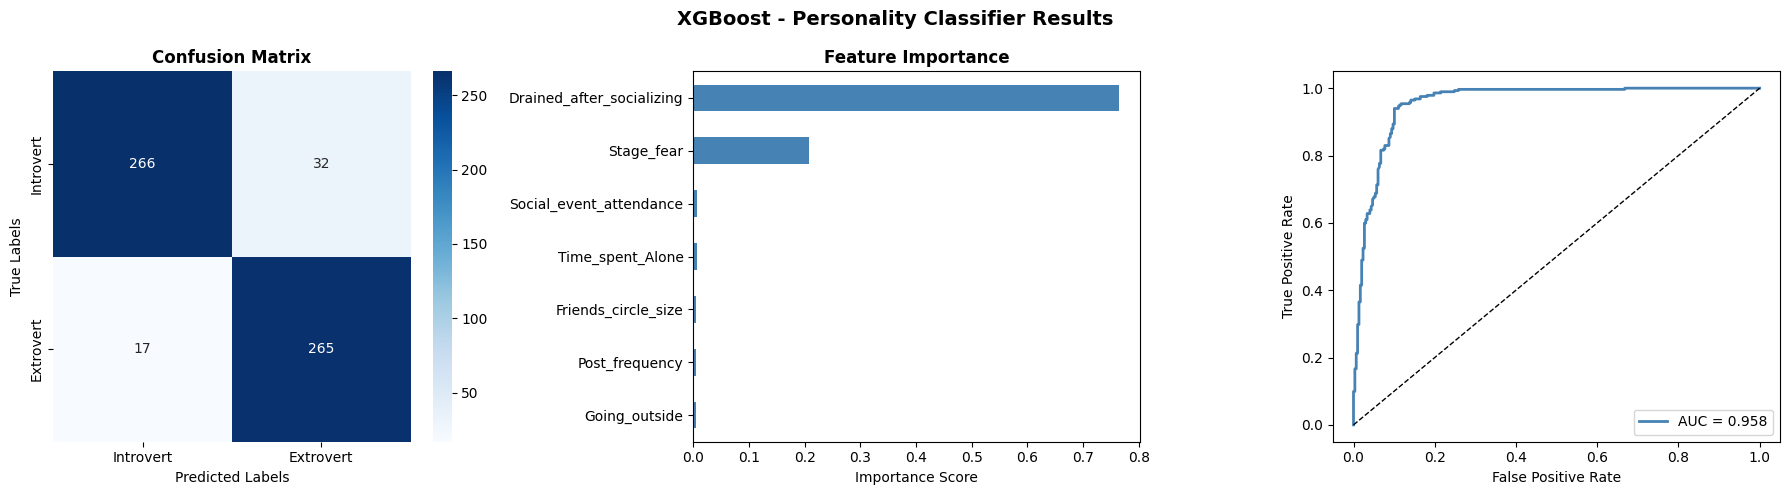

Results chart saved


In [59]:
fig,axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle('XGBoost - Personality Classifier Results', fontsize=14, fontweight='bold')


#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=["Introvert", "Extrovert"],
            yticklabels=["Introvert", "Extrovert"])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

#Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Decryptogen/model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results chart saved")



#Save the Model

In [60]:
joblib.dump(model, '/content/drive/MyDrive/Decryptogen/personality_predictor.pkl')
print("Model saved")

Model saved


#Download the model

In [61]:
from google.colab import files
files.download('/content/drive/MyDrive/Decryptogen/personality_predictor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Test Predictions

In [62]:
def predict_personality(data:dict) -> dict:
  """
  Predict personality from a dictionary of features.
  Accepts the same format as the deployed API.

  Parameters
  ----------

  data : dict with keys:
    Time_spent_Alone        (float, 0-11)
    Stage_fear                (str, 'Yes'/'No')
    Social_event_attendance   (float, 0-10)
    Going_outside             (float, 0-7)
    Drained_after_socializing (str, 'Yes'/'No')
    Friends_circle_size       (float, 0-20)
    Post_frequency            (float, 0-10)

  Returns
  -------
  dict with 'personality' and 'confidence'
  """
  input_df = pd.DataFrame([{
      'Time_spent_Alone'          : data['Time_spent_Alone'],
      'Stage_fear'                : 1 if data['Stage_fear'] == 'Yes' else 0,
      'Social_event_attendance'   : data['Social_event_attendance'],
      'Going_outside'             : data['Going_outside'],
      'Drained_after_socializing' : 1 if data['Drained_after_socializing'] == 'Yes' else 0,
      'Friends_circle_size'       : data['Friends_circle_size'],
      'Post_frequency'            : data['Post_frequency'],
  }])

  pred  = model.predict(input_df)[0]
  proba = model.predict_proba(input_df)[0]
  label = 'Introvert' if pred == 1 else 'Extrovert'
  confidence = round(float(proba[pred]) * 100, 2)

  return {'personality':label, 'confidence':f'{confidence}%'}


#Test with sample inputs

In [63]:
introvert_sample = {
    'Time_spent_Alone': 9,
    'Stage_fear': 'Yes',
    'Social_event_attendance': 1,
    'Going_outside': 1,
    'Drained_after_socializing': 'Yes',
    'Friends_circle_size': 3,
    'Post_frequency': 2
}

extrovert_sample = {
    'Time_spent_Alone': 1,
    'Stage_fear': 'No',
    'Social_event_attendance': 8,
    'Going_outside': 7,
    'Drained_after_socializing': 'No',
    'Friends_circle_size': 14,
    'Post_frequency': 8
}

In [64]:
print("Introvert sample →", predict_personality(introvert_sample))
print("Extrovert sample →", predict_personality(extrovert_sample))

Introvert sample → {'personality': 'Introvert', 'confidence': '94.05%'}
Extrovert sample → {'personality': 'Extrovert', 'confidence': '53.27%'}
